# 03 · Development: baseline, controls, variants and selection

**ORB study, notebook 3 of 5. BTC, 2020-01-01 → 2022-12-31.** Questions: does P0 have an edge before and after
costs; does the anchor, the entry or the exit matter; what does the breakout add over opening momentum and random
entries; and which one challenger, if any, does the frozen rule carry into validation?

Frozen inputs: `results/freeze_F0.json` (rules, code, data) and `results/freeze_F1.json` (the selection, written
before any validation outcome). Costs: `db` = 11.6 bp per round trip plus actual funding; `gross` = price only.

In [1]:
import json, subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

STUDY = Path.cwd()
assert (STUDY / "PREREGISTRATION.md").exists(), "execute from studies/notebooks/orb_study"
sys.path.insert(0, str(STUDY))
import orb_calendars as cal, orb_checks, orb_data, orb_engine as eng, orb_metrics as met, orb_policies as pol
from review_plots import AXIS, INK2, MUTED, NEGATIVE, NEUTRAL, SERIES, style, zero_line
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 80)
RESULTS = STUDY / "results"

def reproduce(symbol, block, pid):
    # Recompute one frozen ledger from the panel and compare it with the saved file.
    import orb_run
    a, b = orb_run.BLOCKS[block]
    mkt = orb_checks.load_market(symbol)
    p = pol.BY_ID[pid]
    fresh = eng.run_policy(mkt, cal.sessions(p.anchor, "2020-01-01", b, shift_min=p.shift_min), p, a, b)
    if "exit_reason" in fresh:
        fresh.loc[(fresh["status"] == "trade") & (fresh["exit_reason"] == "censored_block_end"), "status"] = "censored"
    saved = pd.read_csv(RESULTS / f"run_v1/{block}/{symbol}/{pid}.csv.gz")
    num = ["t0_ms", "H", "L", "trigger_idx", "side", "fill_idx", "fill_px", "stop_px", "exit_idx", "exit_px", "gross_bp", "funding_bp"]
    same = len(fresh) == len(saved) and all(np.allclose(fresh[c].astype(float), saved[c].astype(float), equal_nan=True, rtol=0, atol=1e-9) for c in num)
    return bool(same and fresh["status"].tolist() == saved["status"].tolist())

import orb_run
orb_run.verify_f0()
F0, F1 = (json.loads((RESULTS / f"freeze_{n}.json").read_text()) for n in ("F0", "F1"))
print("F0", F0["created_utc"], "| F1", F1["created_utc"], "| candidates:", F1["candidates"], "|", F1["selection_reason"])
print("frozen files unchanged; ledgers reproduce from the panel:",
      {pid: reproduce("BTCUSDT", "development", pid) for pid in F1["candidates"]})
REP = json.loads((RESULTS / "run_v1/development/development_report.json").read_text())
S = pd.read_csv(RESULTS / "run_v1/development/summary_BTCUSDT.csv")

F0 2026-09-15T07:49:10+00:00 | F1 2026-09-15T07:50:31+00:00 | candidates: ['P0', 'EXT_WIDTH'] | highest eligible development net daily Sharpe


frozen files unchanged; ledgers reproduce from the panel: {'P0': True, 'EXT_WIDTH': True}


## 1. P0 and the whole family, before and after costs

Gross is the price move in bp of entry notional; `net_bp` subtracts 5.8 bp per leg and adds realised funding. The
95% interval and p-value come from a 20-day circular block bootstrap of per-trade expectancy (10,000 draws, seed 42).

In [2]:
g = S[S.scenario == "gross"].set_index("policy")[["trades", "mean_bp", "win_rate"]].rename(columns={"mean_bp": "gross_bp", "win_rate": "gross_win"})
d = S[S.scenario == "db"].set_index("policy")[["mean_bp", "win_rate", "profit_factor", "sharpe_daily_ann", "max_drawdown"]].rename(columns={"mean_bp": "net_bp"})
t = g.join(d)
t["ci95_lo"] = pd.Series({k: v["mean_bp_ci95"][0] for k, v in REP["inference"].items()})
t["ci95_hi"] = pd.Series({k: v["mean_bp_ci95"][2] for k, v in REP["inference"].items()})
t["p_gt0"] = pd.Series({k: v["p_mean_bp_gt0"] for k, v in REP["inference"].items()})
t["break_even_rt_bp"] = pd.Series(REP["break_even_leg_bp"]) * 2
t.round(2)

,trades,gross_bp,gross_win,net_bp,win_rate,profit_factor,sharpe_daily_ann,max_drawdown,ci95_lo,ci95_hi,p_gt0,break_even_rt_bp
policy,,,,,,,,,,,,
P0,735,12.10,0.36,0.65,0.34,1.01,0.06,-0.35,-10.33,11.87,0.45,12.25
CORE_NY_R5_CLOSE,750,11.98,0.25,0.53,0.25,1.01,0.06,-0.33,-10.15,11.34,0.45,12.13
CORE_NY_R5_STOP,751,11.00,0.22,-0.48,0.22,0.99,-0.05,-0.34,-10.31,9.42,0.53,11.12
CORE_NY_R15_STOP,744,13.03,0.33,1.52,0.32,1.03,0.14,-0.40,-9.55,12.61,0.39,13.12
CORE_NY_R30_CLOSE,683,16.41,0.42,4.90,0.39,1.08,0.43,-0.33,-7.24,17.52,0.22,16.50
CORE_NY_R30_STOP,706,15.27,0.41,3.77,0.38,1.06,0.33,-0.36,-8.03,15.72,0.27,15.37
CORE_NY_R60_CLOSE,515,17.22,0.46,5.77,0.43,1.09,0.42,-0.39,-10.96,23.06,0.24,17.37
CORE_NY_R60_STOP,568,18.92,0.46,7.38,0.43,1.12,0.57,-0.35,-7.78,22.81,0.16,18.98
CORE_LDN_R5_CLOSE,748,2.39,0.19,-9.14,0.19,0.78,-1.23,-0.52,-16.73,-1.14,0.99,2.46


## 2. The anchor matters more than the rule

Gross expectancy for every anchor and range length (close entries solid, resting-stop entries dotted). The grey
line is the decision-bearing round trip of 11.6 bp: a policy has to clear it just to break even.

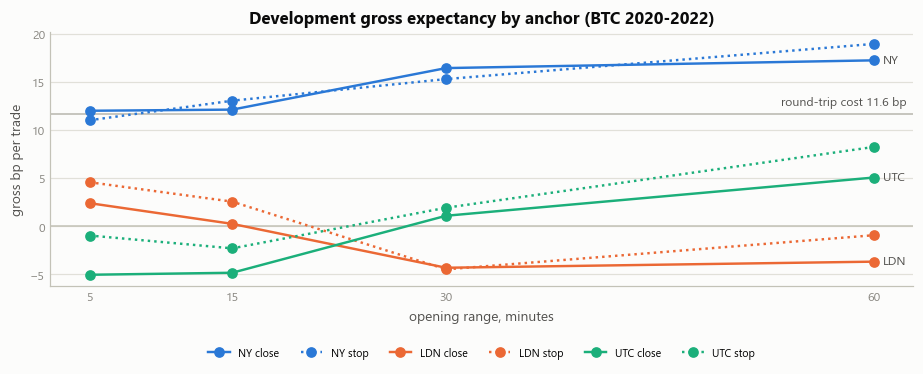

In [3]:
gross = S[S.scenario == "gross"].set_index("policy")["mean_bp"]
fig, ax = plt.subplots(figsize=(8.5, 3.6))
for i, anchor in enumerate(("NY", "LDN", "UTC")):
    for entry, ls in (("CLOSE", "-"), ("STOP", ":")):
        ids = ["P0" if (anchor, m, entry) == ("NY", 15, "CLOSE") else f"CORE_{anchor}_R{m}_{entry}" for m in (5, 15, 30, 60)]
        ax.plot([5, 15, 30, 60], [gross[k] for k in ids], ls, marker="o", color=SERIES[i], label=f"{anchor} {entry.lower()}")
    ax.annotate(anchor, xy=(60, gross[f"CORE_{anchor}_R60_CLOSE"]), xytext=(6, 0), textcoords="offset points", fontsize=8, color=INK2, va="center")
style(ax); zero_line(ax); zero_line(ax, 11.6, "round-trip cost 11.6 bp", color=NEUTRAL)
ax.set_xticks([5, 15, 30, 60]); ax.set_xlabel("opening range, minutes"); ax.set_ylabel("gross bp per trade")
ax.set_title("Development gross expectancy by anchor (BTC 2020-2022)")
ax.legend(ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=7)
plt.tight_layout(); plt.show()

## 3. Controls: what does the breakout itself add?

- **Opening momentum** enters at 09:45 in the range candle's direction without waiting for a break.
- **Clock long / short** enter at 09:45 in a fixed direction with the same stop rule.
- **Placebo** shifts the whole rule by ±1–2 hours on the same dates.
- **Random direction** keeps P0's entries and stop distance but flips a seeded coin for the side (200 seeds);
  **random time** also draws the entry minute (200 seeds).

,trades,gross_bp,net_bp,gross_win,sharpe_daily_ann
policy,,,,,
P0,735,12.10,0.65,0.36,0.06
CTL_MOMENTUM,752,10.65,-0.90,0.25,-0.09
CTL_CLOCK_LONG,752,7.12,-4.92,0.18,-0.61
CTL_CLOCK_SHORT,752,6.77,-4.31,0.19,-0.54
CTL_FADE,733,1.09,-10.52,0.55,-2.07
CTL_PLACEBO_M120,745,-8.91,-20.55,0.21,-2.44
CTL_PLACEBO_M60,731,-4.05,-15.66,0.25,-1.71
CTL_PLACEBO_P60,741,7.20,-4.30,0.31,-0.46
CTL_PLACEBO_P120,742,-0.96,-12.60,0.27,-1.39


,p0_mean_bp_db,share_seeds_at_or_above_p0_db,seed_mean_bp_db_quantiles,p0_mean_bp_gross,share_seeds_at_or_above_p0_gross
random_direction,0.645781,0.12,"[-12.501637768489786, -4.917881803183226, 2.34...",12.102663,0.12
random_time,0.645781,0.025,"[-17.831643580117415, -9.902594437227865, -0.6...",12.102663,0.03


paired daily difference vs opening momentum (db):


,mean_daily_diff,ci95,p_gt0
P0_minus_momentum,0.000105,"[-0.0004400117877837455, 9.390078879686016e-05...",0.349465
EXT_WIDTH_minus_momentum,0.000326,"[-0.0002472186610661276, 0.0003301350687265467...",0.132987


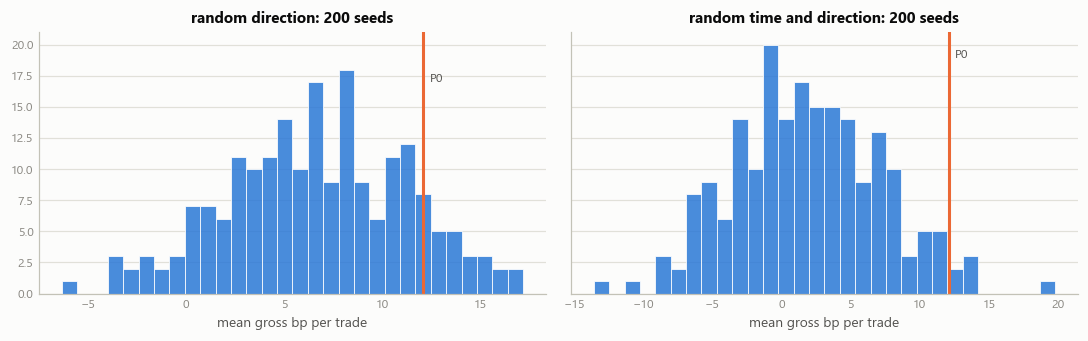

In [4]:
ctl_ids = ["P0", "CTL_MOMENTUM", "CTL_CLOCK_LONG", "CTL_CLOCK_SHORT", "CTL_FADE", "CTL_PLACEBO_M120", "CTL_PLACEBO_M60", "CTL_PLACEBO_P60", "CTL_PLACEBO_P120"]
display(t.loc[ctl_ids, ["trades", "gross_bp", "net_bp", "gross_win", "sharpe_daily_ann"]].round(2))
display(pd.DataFrame(REP["random_controls"]).T)
print("paired daily difference vs opening momentum (db):")
display(pd.DataFrame(REP["paired_vs_momentum"]).T)
rd, rt = pd.read_csv(RESULTS / "run_v1/development/random_direction.csv"), pd.read_csv(RESULTS / "run_v1/development/random_time.csv")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, df, name in zip(axes, (rd, rt), ("random direction", "random time and direction")):
    ax.hist(df.mean_bp_gross, bins=30, color=SERIES[0], alpha=0.85, edgecolor="white", linewidth=0.6)
    ax.axvline(t.loc["P0", "gross_bp"], color=SERIES[1], linewidth=2)
    ax.annotate("P0", xy=(t.loc["P0", "gross_bp"], ax.get_ylim()[1] * 0.9), xytext=(4, 0), textcoords="offset points", fontsize=8, color=INK2)
    style(ax); ax.set_title(f"{name}: 200 seeds", fontsize=10); ax.set_xlabel("mean gross bp per trade")
plt.tight_layout(); plt.show()

## 4. Exits: in development every earlier exit made it worse

The exit-event addendum and the draft's target and 60-minute arms, each changing only P0's exit. Gross in blue,
after costs in orange. Only removing the 16:00 exit raised the gross in development; notebook 05 follows every arm
through 2026 on both assets.

,trades,gross_bp,net_bp,gross_win,max_drawdown
policy,,,,,
"P0: opposite stop, 16:00 exit",735,12.10,0.65,0.36,-0.35
"no time exit (hold to stop, 7-day cap)",428,32.74,17.93,0.10,-0.72
3R target,735,8.35,-3.09,0.38,-0.37
2R target,735,6.56,-4.92,0.41,-0.48
1R target,735,3.41,-8.17,0.54,-0.49
exit on VWAP cross,735,4.63,-6.94,0.30,-0.46
exit on 15m close back in range,735,4.14,-7.42,0.16,-0.56
exit on 1m close back in range,735,1.79,-9.78,0.09,-0.53
"trailing stop, one range width",735,1.99,-9.56,0.40,-0.52


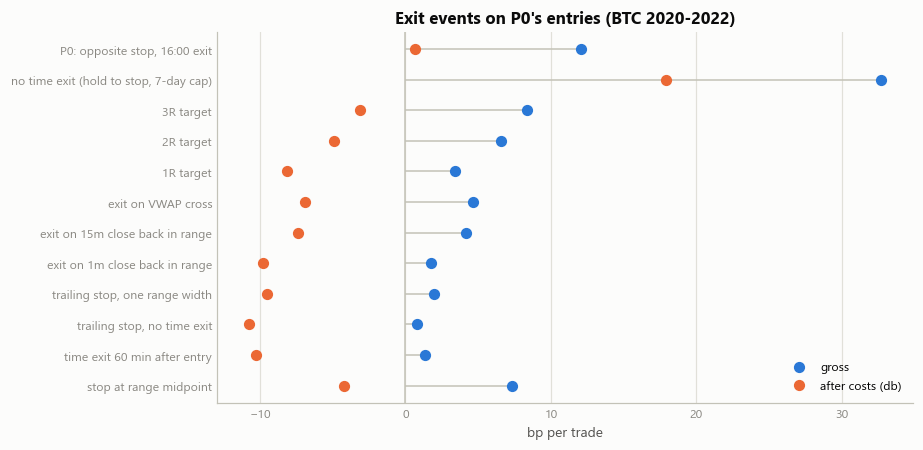

In [5]:
exit_ids = ["P0", "X_NOTIME", "EXT_TGT3R", "EXT_TGT2R", "EXT_TGT1R", "X_VWAP", "X_REENTER15M", "X_REENTER1M", "X_TRAIL", "X_TRAIL_NOTIME", "EXT_TX60", "EXT_STOPMID"]
labels = {"P0": "P0: opposite stop, 16:00 exit", "X_NOTIME": "no time exit (hold to stop, 7-day cap)", "EXT_TGT3R": "3R target",
          "EXT_TGT2R": "2R target", "EXT_TGT1R": "1R target", "X_VWAP": "exit on VWAP cross", "X_REENTER15M": "exit on 15m close back in range",
          "X_REENTER1M": "exit on 1m close back in range", "X_TRAIL": "trailing stop, one range width", "X_TRAIL_NOTIME": "trailing stop, no time exit",
          "EXT_TX60": "time exit 60 min after entry", "EXT_STOPMID": "stop at range midpoint"}
e = t.loc[exit_ids, ["trades", "gross_bp", "net_bp", "gross_win", "max_drawdown"]]
display(e.rename(index=labels).round(2))
fig, ax = plt.subplots(figsize=(8.5, 4.2))
yy = np.arange(len(exit_ids))[::-1]
ax.hlines(yy, 0, e.gross_bp, color=AXIS, linewidth=1)
ax.scatter(e.gross_bp, yy, color=SERIES[0], s=40, zorder=3, label="gross")
ax.scatter(e.net_bp, yy, color=SERIES[1], s=40, zorder=3, label="after costs (db)")
ax.set_yticks(yy); ax.set_yticklabels([labels[k] for k in exit_ids], fontsize=8)
style(ax, grid_axis="x"); ax.axvline(0, color=AXIS, linewidth=1)
ax.set_xlabel("bp per trade"); ax.set_title("Exit events on P0's entries (BTC 2020-2022)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 5. Selection by the frozen rule

Eligible: at least 100 trades, positive net expectancy, positive in at least two of the three years. The highest net
daily Sharpe wins; ties within 0.02 go to fewer changed components. CORE_NY_R60_STOP had the highest Sharpe (0.565);
EXT_WIDTH (0.557) was within 0.02 with one changed component instead of two, so EXT_WIDTH is the challenger. Both
beat P0's 0.061.

In [6]:
sel = pd.read_csv(RESULTS / "run_v1/development/selection_table.csv").sort_values("sharpe", ascending=False)
display(sel.head(10).round(3))
yearly = pd.read_csv(RESULTS / "run_v1/development/yearly_db_BTCUSDT.csv", index_col=0)
yearly.loc[["P0", "EXT_WIDTH", "CORE_NY_R60_STOP", "X_NOTIME"]].round(2)

,policy,trades,mean_bp,sharpe,years_positive,changed_components,eligible
6,CORE_NY_R60_STOP,568,7.385,0.565,2,2,True
29,EXT_WIDTH,381,7.600,0.557,3,1,True
41,X_NOTIME,428,17.933,0.520,2,1,True
3,CORE_NY_R30_CLOSE,683,4.902,0.426,1,1,False
5,CORE_NY_R60_CLOSE,515,5.774,0.425,1,1,False
4,CORE_NY_R30_STOP,706,3.769,0.330,1,2,False
26,EXT_RVOL10,276,4.829,0.230,2,1,True
37,INT_RVOL10_TGT2R,276,4.596,0.224,2,2,True
25,EXT_GATE,577,2.493,0.198,2,1,True
31,EXT_DL180,744,1.856,0.176,1,1,False


,2020,2021,2022
P0,-2.85,-7.69,12.62
EXT_WIDTH,6.20,2.00,14.90
CORE_NY_R60_STOP,-5.38,7.03,22.03
X_NOTIME,69.02,-42.14,50.62


## 6. How much can 46 trials and three years say?

Romano–Wolf StepM over all 46 family return series rejects nothing (best t = 0.98 against a critical value of 2.61).
The deflated Sharpe ratio of the challenger is 0.004 at 46 trials. The minimum detectable effect at 80% power is about
17 bp per trade for the two-year validation block, eight times the +2 bp hurdle: validation can reject large effects
but cannot confirm small ones.

In [7]:
print("StepM rejected:", REP["stepm"]["rejected"], "| final critical value", round(REP["stepm"]["final_critical_value"], 3))
display(pd.Series(REP["stepm"]["t_stats"]).sort_values(ascending=False).head(8).round(2).to_frame("t"))
display(pd.DataFrame({c: {n: (round(v["dsr"], 4) if v else None) for n, v in dd.items()} for c, dd in REP["dsr"].items()}).rename_axis("trials"))
pd.Series(REP["mde"]).round(2).to_frame("minimum detectable effect")

StepM rejected: [] | final critical value 2.609


,t
CORE_NY_R60_STOP,0.98
EXT_WIDTH,0.97
X_NOTIME,0.90
CORE_NY_R30_CLOSE,0.74
CORE_NY_R60_CLOSE,0.74
CORE_NY_R30_STOP,0.57
EXT_RVOL10,0.40
INT_RVOL10_TGT2R,0.39


,P0,EXT_WIDTH
trials,,
46,0.0004,0.0045
100,0.0001,0.0010
200,0.0000,0.0003


,minimum detectable effect
p0_dev_se_bp,5.69
dev_trades,735.00
validation_mde80_bp,17.33
lockbox_mde80_bp,18.78
